In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
%matplotlib inline

In [3]:
cwd = Path.cwd()
project_root = cwd.parent
data_path = project_root / "data" / "Online Retail.xlsx"

In [4]:
exfile = pd.ExcelFile(str(data_path))

In [5]:
exfile.sheet_names

['Online Retail']

In [6]:
data = exfile.parse("Online Retail")

In [7]:
data.shape

(541909, 8)

In [8]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
data["Country"].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [10]:
data['Description'].unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ..., 'lost',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], shape=(4224,), dtype=object)

## Doing some feature engineering, Creating Features RFM(Recency, Frequency, Monetary Value)

In [11]:
data = data[data["Quantity"] > 0]

Spliting the data based on the threshold_date

In [13]:
latest_date = max(data["InvoiceDate"])
threshold_date = latest_date - pd.Timedelta(days=30)

In [14]:
data = data[data["InvoiceDate"] < threshold_date]

In [15]:
data.shape

(442614, 8)

In [16]:
data["InvoiceDate"].unique()

<DatetimeArray>
['2010-12-01 08:26:00', '2010-12-01 08:28:00', '2010-12-01 08:34:00',
 '2010-12-01 08:35:00', '2010-12-01 08:45:00', '2010-12-01 09:00:00',
 '2010-12-01 09:01:00', '2010-12-01 09:02:00', '2010-12-01 09:09:00',
 '2010-12-01 09:32:00',
 ...
 '2011-11-09 12:20:00', '2011-11-09 12:25:00', '2011-11-09 12:26:00',
 '2011-11-09 12:29:00', '2011-11-09 12:30:00', '2011-11-09 12:32:00',
 '2011-11-09 12:34:00', '2011-11-09 12:38:00', '2011-11-09 12:45:00',
 '2011-11-09 12:49:00']
Length: 16391, dtype: datetime64[us]

In [17]:
max(data["InvoiceDate"]), min(data['InvoiceDate'])

(Timestamp('2011-11-09 12:49:00'), Timestamp('2010-12-01 08:26:00'))

In [18]:
data.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 442614 entries, 0 to 452024
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    442614 non-null  object        
 1   StockCode    442614 non-null  object        
 2   Description  442081 non-null  object        
 3   Quantity     442614 non-null  int64         
 4   InvoiceDate  442614 non-null  datetime64[us]
 5   UnitPrice    442614 non-null  float64       
 6   CustomerID   332343 non-null  float64       
 7   Country      442614 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 30.4+ MB


In [19]:
recency = data.groupby(by="CustomerID")["InvoiceDate"].max()

In [20]:
latest_date = data["InvoiceDate"].max()

In [21]:
recency = latest_date - recency

In [22]:
recency = recency.apply(lambda x: x.days)

In [23]:
recency

CustomerID
12346.0    295
12347.0      9
12348.0     44
12350.0    279
12352.0      5
          ... 
18280.0    247
18281.0    150
18282.0     95
18283.0     12
18287.0     12
Name: InvoiceDate, Length: 4070, dtype: int64

In [24]:
frequency = data.groupby(by="CustomerID")["InvoiceDate"].count()

In [25]:
frequency

CustomerID
12346.0      1
12347.0    171
12348.0     31
12350.0     17
12352.0     85
          ... 
18280.0     10
18281.0      7
18282.0      7
18283.0    487
18287.0     70
Name: InvoiceDate, Length: 4070, dtype: int64

In [26]:
data["TotalMoneySpent"] = data["Quantity"].multiply(data["UnitPrice"])

In [27]:
money_spent = data.groupby(by="CustomerID")["TotalMoneySpent"].sum()
money_spent

CustomerID
12346.0    77183.60
12347.0     4085.18
12348.0     1797.24
12350.0      334.40
12352.0     2506.04
             ...   
18280.0      180.60
18281.0       80.82
18282.0      100.21
18283.0     1235.32
18287.0     1837.28
Name: TotalMoneySpent, Length: 4070, dtype: float64

In [28]:
data[data["CustomerID"] == 12346.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalMoneySpent
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [29]:
customers_u_data = pd.DataFrame(data={
    "Recency": recency,
    "Frequency": frequency,
    "MoneySpent": money_spent
})

In [30]:
customers_u_data

,Recency,Frequency,MoneySpent
CustomerID,,,
12346.0,295,1,77183.60
12347.0,9,171,4085.18
12348.0,44,31,1797.24
12350.0,279,17,334.40
12352.0,5,85,2506.04
...,...,...,...
18280.0,247,10,180.60
18281.0,150,7,80.82
18282.0,95,7,100.21


In [31]:
scalar = StandardScaler()
X = scalar.fit_transform(customers_u_data.to_numpy())

In [32]:
inertias = []
s_scores = []
for i in range(2, 10):
    model = KMeans(n_clusters=i+1)
    clusters = model.fit_predict(X)
    s_score = silhouette_score(X, clusters)
    s_scores.append(s_score)
    inertias.append(model.inertia_)

In [33]:
inertias, s_scores

([5279.962078046613,
  4077.7251394456425,
  3130.8547254104656,
  2547.792535409701,
  2287.903311679259,
  1920.2597713617918,
  1768.9178859873764,
  1311.6825179960113],
 [0.5716868816635771,
  0.5713624313381923,
  0.5889606274271711,
  0.5725837810672892,
  0.44974853996541664,
  0.5637558920948876,
  0.4331282624557959,
  0.4391874490110286])

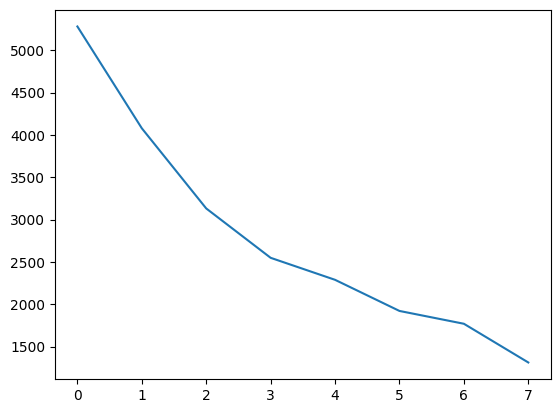

In [34]:
plt.plot(inertias);

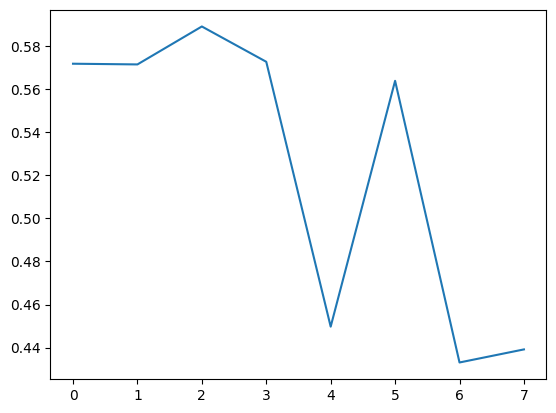

In [35]:
plt.plot(s_scores);

In [36]:
best_model = KMeans(n_clusters=4)
customers_u_data["Cluster"] = best_model.fit_predict(X)

In [37]:
customers_u_data.groupby("Cluster")[["Recency", "Frequency", "MoneySpent"]].mean()

,Recency,Frequency,MoneySpent
Cluster,,,
0,226.230769,27.920484,575.705066
1,39.353469,92.295823,1905.622939
2,2.769231,2315.615385,54151.965385
3,5.333333,851.666667,223221.313333


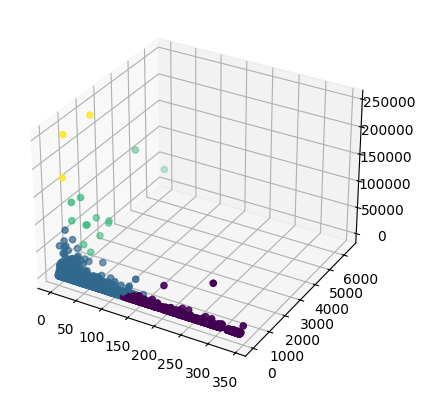

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xs=customers_u_data["Recency"], ys=customers_u_data["Frequency"], zs=customers_u_data["MoneySpent"], c=customers_u_data["Cluster"]);

plt.show()

In [39]:
fig = px.scatter_3d(customers_u_data, 
                    x="Recency", 
                    y="Frequency", 
                    z="MoneySpent",
                    color="Cluster")
fig.show()

#### You can clearly see the outliers, And as we know the clusters created by kmeans are influenced by the outliers, so we have 2 option.
1. we can either take the 99 percentile of the data.
2. we can use K-midoids

I am going with option 1.

In [40]:
for column in ["Recency", "Frequency", "MoneySpent"]:
    percentile_99 = customers_u_data[column].quantile(0.99)
    customers_u_data[column] = customers_u_data[column].clip(upper=percentile_99)

In [41]:
X = scalar.fit_transform(customers_u_data[["Recency", "Frequency", "MoneySpent"]].to_numpy())
inertias = []
s_scores = []
for i in range(2, 10):
    model = KMeans(n_clusters=i+1)
    clusters = model.fit_predict(X)
    score = silhouette_score(X, clusters)
    s_scores.append(score)
    inertias.append(model.inertia_)

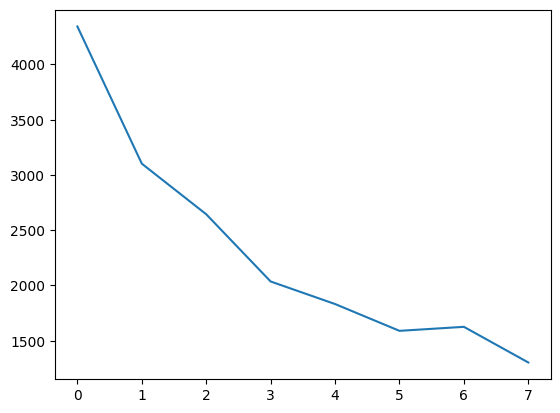

In [42]:
plt.plot(inertias);

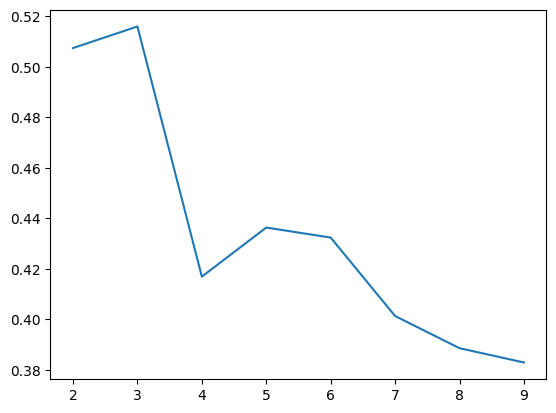

In [43]:
plt.plot([i for i in range(2, 10)], s_scores);

In [44]:
best_model = KMeans(n_clusters=3)
customers_u_data["Cluster"] = best_model.fit_predict(X)

In [45]:
customers_u_data.columns

Index(['Recency', 'Frequency', 'MoneySpent', 'Cluster'], dtype='str')

In [46]:
clusters = customers_u_data.groupby("Cluster")[['Recency', 'Frequency', 'MoneySpent']].mean()
clusters

,Recency,Frequency,MoneySpent
Cluster,,,
0,41.777393,63.670127,1136.013334
1,226.541958,26.144231,437.016793
2,24.440000,329.743138,7590.795108


In [47]:
fig = px.scatter_3d(customers_u_data, 
                    x="Recency", 
                    y="Frequency", 
                    z="MoneySpent",
                    color="Cluster")
fig.show()

In [48]:
score = silhouette_score(X, customers_u_data["Cluster"])

In [49]:
score

0.507392300670355

#### Clustering part is done now we have to work on purchase prediction that we will do with decision trees

Here is what we are going to do, We will use decision trees to predict: **Will this customer purchase again in the next 90 days?**

In [50]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalMoneySpent
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [51]:
data.shape

(442614, 9)

In [52]:
data.to_csv(path_or_buf=project_root / "data" / "cleaned_data.csv", index=False)

In [53]:
customers_u_data.head()

,Recency,Frequency,MoneySpent,Cluster
CustomerID,,,,
12346.0,295,1.0,17174.14,2
12347.0,9,171.0,4085.18,0
12348.0,44,31.0,1797.24,0
12350.0,279,17.0,334.40,1
12352.0,5,85.0,2506.04,0


In [54]:
customers_u_data.to_csv(path_or_buf=project_root / "data" / "customers_u_data.csv")